# harmonix - example / demo

End-to-end demo of the `harmonix` library on the bundled example data. Primary use is a single
`ds, y` series. Every graph is a one-call method: `model.plot_fit()`, `plot_components()`,
`plot_forecast()`, `plot_variable_amplitude()`, `plot_pair_selection()`, `compare_to()`.

Run from the repo root. Regenerate with: `jupyter nbconvert --to notebook --execute examples/demo.ipynb`.

In [1]:
# locate the repo root (works whether you launch jupyter from the repo or from examples/)
import os, sys
root = os.getcwd()
while root != os.path.dirname(root) and not os.path.isdir(os.path.join(root, 'src', 'harmonix')):
    root = os.path.dirname(root)
os.chdir(root); sys.path.insert(0, os.path.join(root, 'src'))
import numpy as np, matplotlib.pyplot as plt
%matplotlib inline
from harmonix import HarmonicModel, Series, plot_comparison
print('harmonix ready  (root:', root, ')')

harmonix ready  (root: D:\VsCode\Marchev )


## 1. Load a single series (ds, y) - JSON / CSV / Excel / DataFrame

length 18260


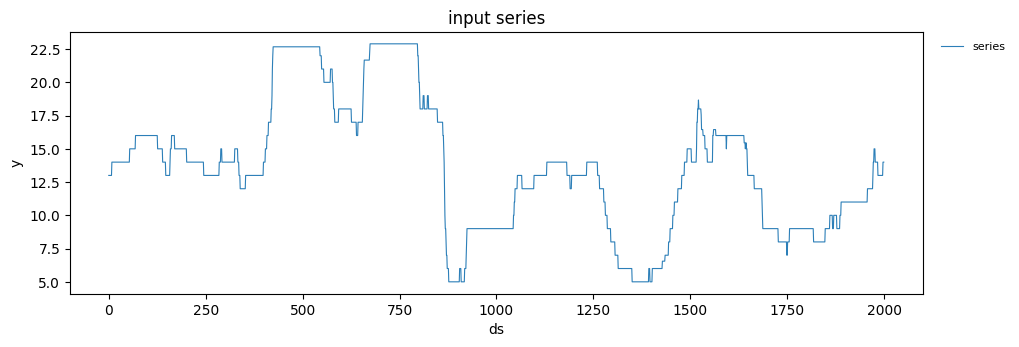

In [2]:
series = Series.from_json('data/before_1.json').concat(Series.from_json('data/before_2.json'), name='series')
print('length', len(series))
series.plot(window=2000); plt.show()

## 2. Fit

In [3]:
model = HarmonicModel(min_r2_gain=0.02, solver='lstsq', maxiter=120, verbose=True).fit(series)
print('pairs', model.n_pairs_, ' R2', round(model.r2_, 4))

 Pair 1: T1=10382.6, T2=80587.7  R2=0.5176  BIC=105875.8


 Pair 2: T1=2022.4, T2=2416.1  R2=0.6297  BIC=101085.4


 Pair 3: T1=1511.3, T2=5518.5  R2=0.6781  BIC=98567.6


 Pair 4: T1=446.8, T2=883.6  R2=0.7154  BIC=96356.6


 Pair 5: T1=762.5, T2=1100.9  R2=0.7410  BIC=94677.9


 Pair 6: T1=1354.0, T2=2869.4  R2=0.7618  BIC=93186.9


 Pair 7: T1=623.6, T2=1216.1  R2=0.7851  BIC=91347.6


=== R2 gain 1.71e-02 < 2.0e-02 -> stop ===
pairs 7  R2 0.7851


## 3. Summary

In [4]:
model.summary(grey_zone_label='grey zone');

HarmonicModel summary  -  series
observations        18260      pairs               7
parameters             29      solver          lstsq
R2                 0.7851      RMSE           2.9295
MAE                2.3656      MAPE           13.18%
resid std          2.9295
BIC               91357.4      AIC           91130.8
------------------------------------------------------------------
components:  trend 1   cycle 6   grey zone 0   (var-amp pairs 0)
 j        T1    A1   phi1        T2     A2   phi2  2T1T2/(T1+T2)/n Condition 1  (T1+T2)/|T1-T2| Condition 2  T/TA Condition 3 Variable Amplitude  Partial R2    R2 T1 is Trend T2 is Trend T1 is Cycle T2 is Cycle
 0 10382.598 5.830 -2.556 80587.700 23.409  0.902            1.007          No            1.296          No 0.772          No                 No       0.518 0.518          No         Yes         Yes          No
 1  2022.416 2.472  0.455  2416.073  2.263 -0.825            0.121         Yes           11.275         Yes 0.089         

## 4. Fit / components / residuals

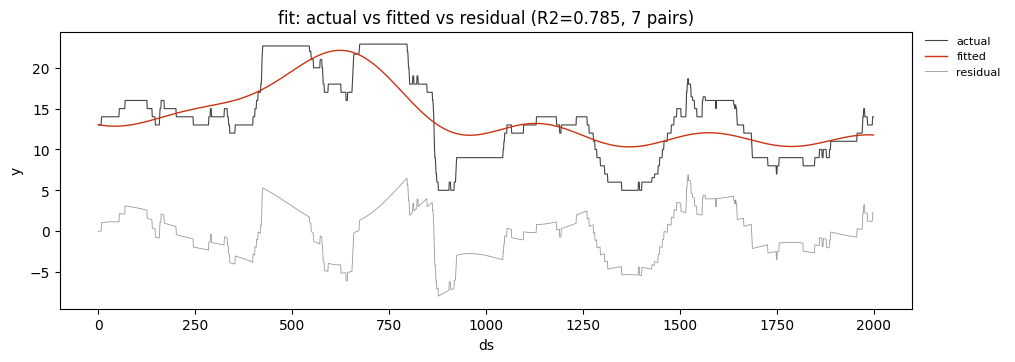

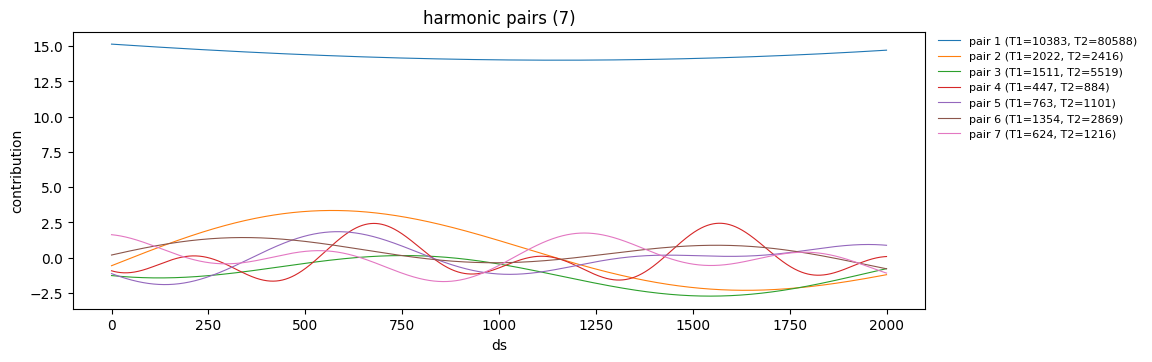

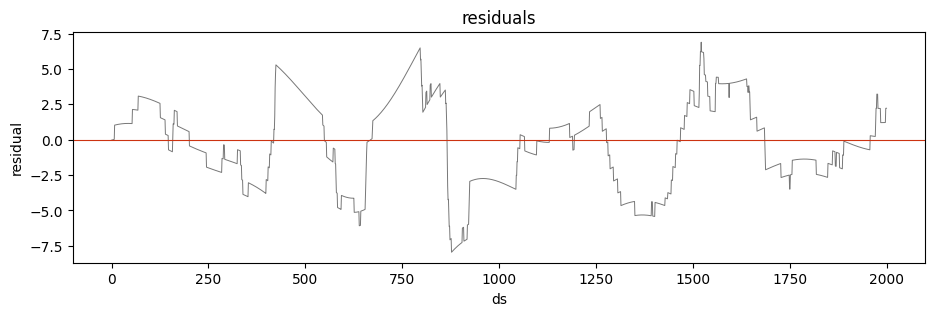

In [5]:
model.plot_fit(window=2000); plt.show()
model.plot_components(window=2000); plt.show()
model.plot_residuals(window=2000); plt.show()

## 5. Forecast

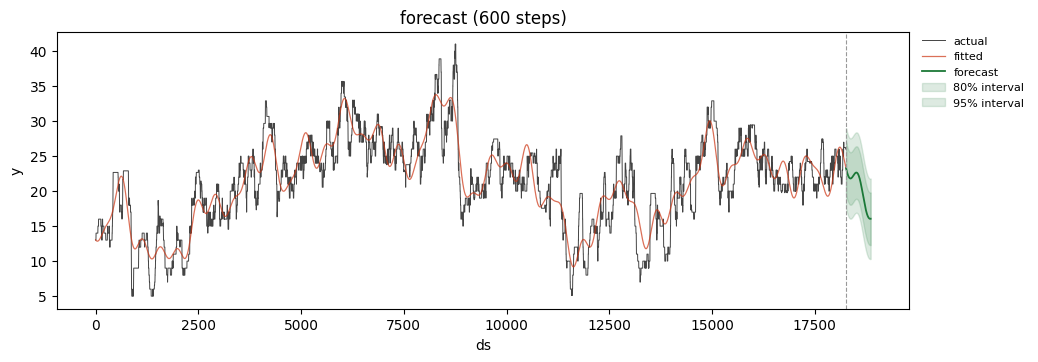

In [6]:
model.plot_forecast(600, level=[80, 95]); plt.show()

## 6. Variable-amplitude (beat)

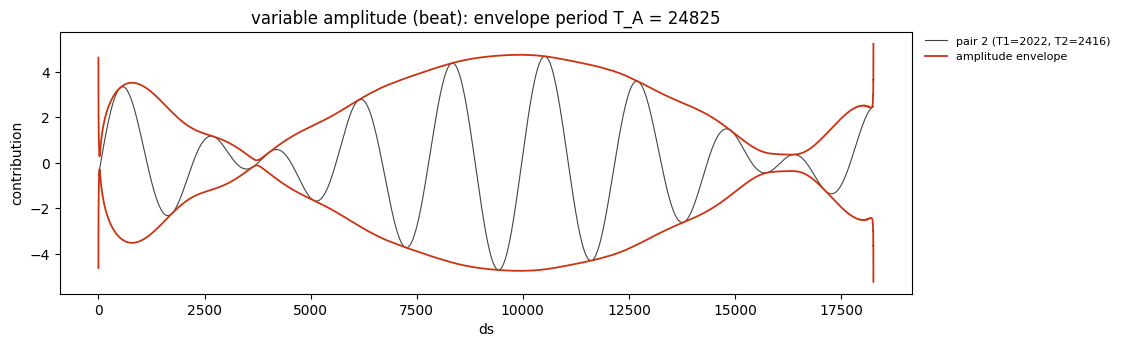

var-amp pairs: []


In [7]:
model.plot_variable_amplitude(); plt.show()
print('var-amp pairs:', [p['pair'] for p in model.variable_amplitude_pairs()])

## 7. Pair-selection methodology

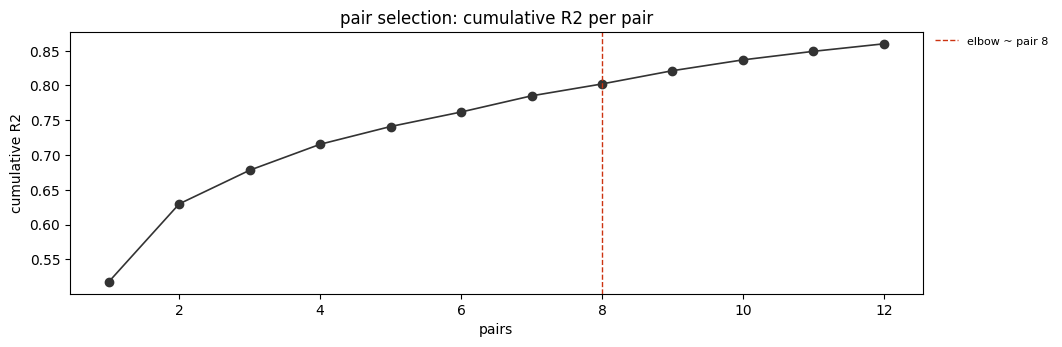

In [8]:
mc = HarmonicModel(max_pairs=12, solver='lstsq', maxiter=120).fit(series)
mc.plot_pair_selection(); plt.show()

## 8. Compare two series (optional - e.g. before vs after)

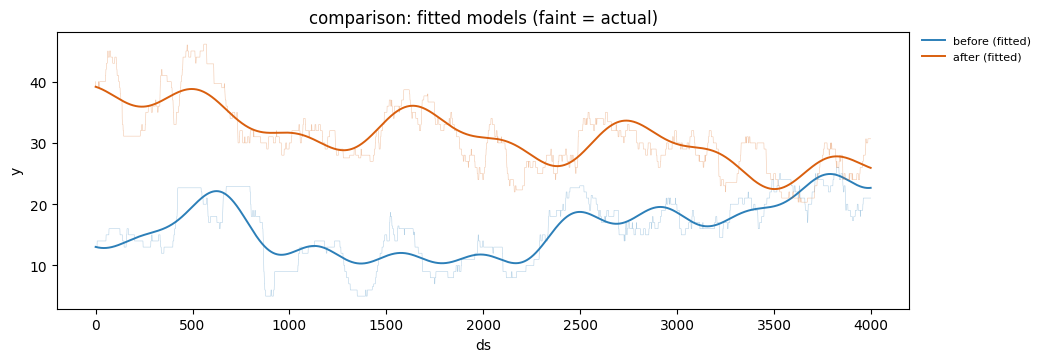

before {'trend': 1, 'cycle': 6, 'grey zone': 0}
after  {'trend': 1, 'cycle': 4, 'grey zone': 1}


In [9]:
after = Series.from_json('data/after_1.json').concat(Series.from_json('data/after_2.json'), name='after')
ma = HarmonicModel(min_r2_gain=0.02, solver='lstsq', maxiter=120).fit(after)
model.compare_to(ma, labels=['before','after']); plt.show()
print('before', model.count_components(grey_zone_label='grey zone'))
print('after ', ma.count_components(grey_zone_label='grey zone'))